<a href="https://colab.research.google.com/github/sanskrutimishra2307-droid/Machine_Vision_Lab/blob/main/MV02_016.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving Screenshot 2026-07-07 114527.png to Screenshot 2026-07-07 114527.png


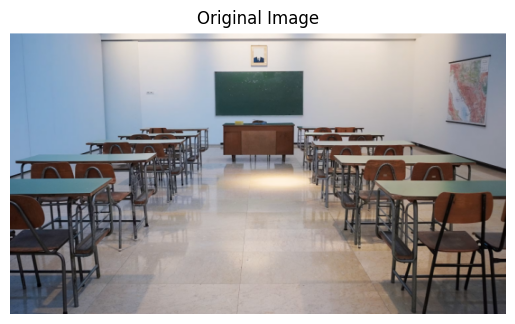

In [2]:
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
image = cv2.imread(image_name)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

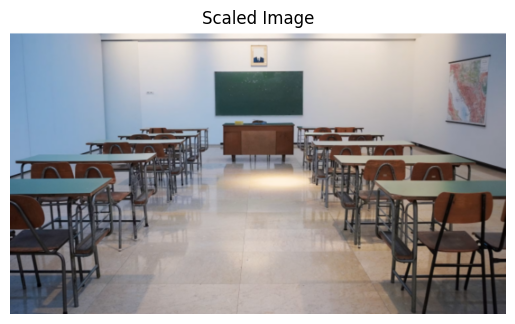

In [3]:
scaled = cv2.resize(image, None, fx=1.5, fy=1.5)

plt.imshow(scaled)
plt.title("Scaled Image")
plt.axis("off")
plt.show()

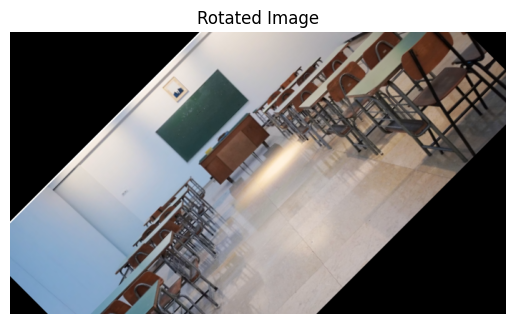

In [4]:
height, width = image.shape[:2]

center = (width//2, height//2)

rotation_matrix = cv2.getRotationMatrix2D(center,45,1)

rotated = cv2.warpAffine(image,
                         rotation_matrix,
                         (width,height))

plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis("off")
plt.show()

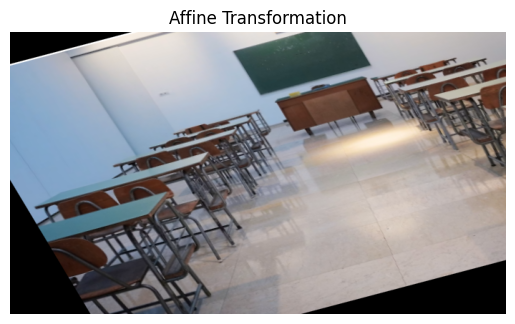

In [5]:
rows, cols = image.shape[:2]

pts1 = np.float32([[50,50],
                   [200,50],
                   [50,200]])

pts2 = np.float32([[10,100],
                   [200,50],
                   [100,250]])

matrix = cv2.getAffineTransform(pts1,pts2)

affine = cv2.warpAffine(image,
                        matrix,
                        (cols,rows))

plt.imshow(affine)
plt.title("Affine Transformation")
plt.axis("off")
plt.show()

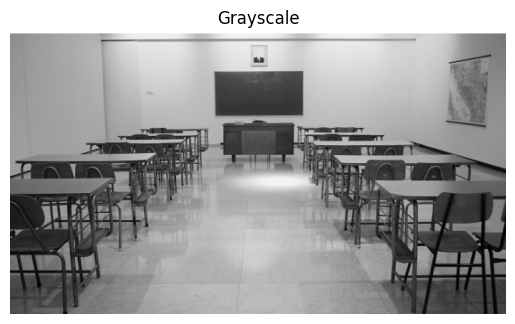

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray,cmap='gray')
plt.title("Grayscale")
plt.axis("off")
plt.show()

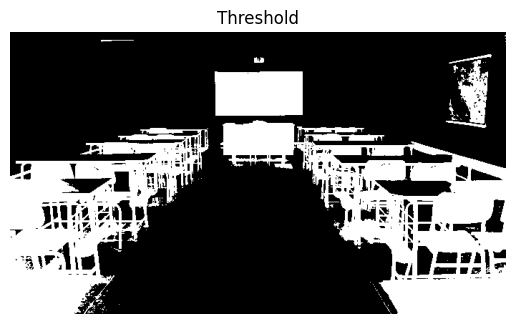

In [7]:
_, thresh = cv2.threshold(gray,
                          120,
                          255,
                          cv2.THRESH_BINARY_INV)

plt.imshow(thresh,cmap='gray')
plt.title("Threshold")
plt.axis("off")
plt.show()

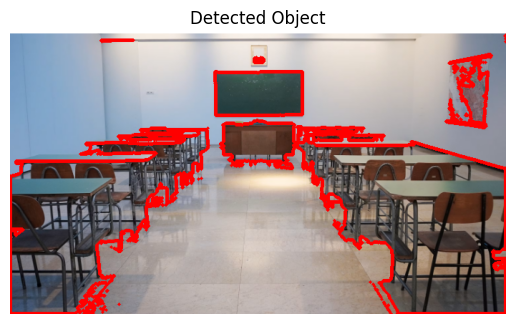

In [8]:
contours, _ = cv2.findContours(thresh,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

output = image.copy()

cv2.drawContours(output,
                 contours,
                 -1,
                 (255,0,0),
                 3)

plt.imshow(output)
plt.title("Detected Object")
plt.axis("off")
plt.show()

Width (pixels): 399
Height (pixels): 271


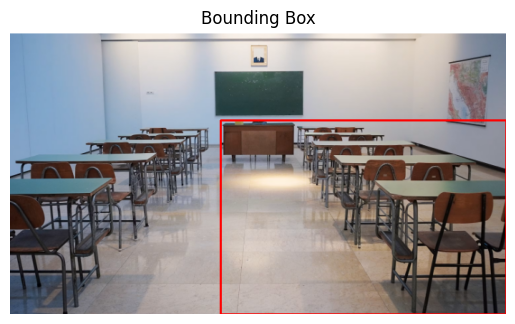

In [9]:


largest = max(contours, key=cv2.contourArea)

x,y,w,h = cv2.boundingRect(largest)

print("Width (pixels):", w)
print("Height (pixels):", h)

measurement = image.copy()

cv2.rectangle(measurement,
              (x,y),
              (x+w,y+h),
              (255,0,0),
              2)

plt.imshow(measurement)
plt.title("Bounding Box")
plt.axis("off")
plt.show()

In [10]:
pixel_per_mm = 10

width_mm = w/pixel_per_mm
height_mm = h/pixel_per_mm

print("Estimated Width:", round(width_mm,2),"mm")
print("Estimated Height:", round(height_mm,2),"mm")

Estimated Width: 39.9 mm
Estimated Height: 27.1 mm
